Laboratory 1: Digital Image Processing

In [3]:
% pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.3/48.3 MB 4.0 MB/s  0:00:12m0:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from PIL import Image
import cv2

print("Libraries imported successfully")

Libraries imported successfully


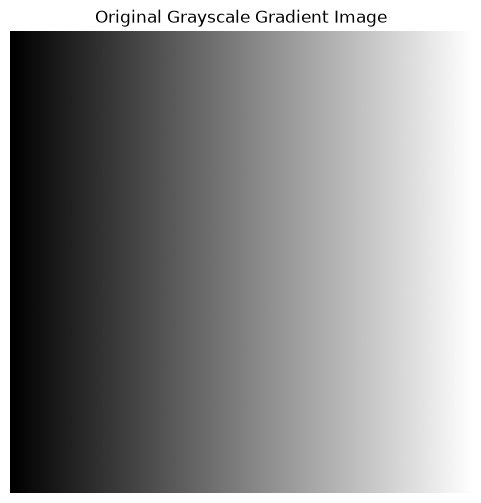

In [4]:
# Create the Original Grayscale Image

width = 512
height = 512

gradient = np.tile(
    np.linspace(0,255, width, dtype=np.uint8),
    (height, 1)
)

plt.figure(figsize=(6,6))
plt.imshow(gradient, cmap="gray", vmin=0, vmax=255)
plt.title("Original Grayscale Gradient Image")
plt.axis("off")
plt.show()

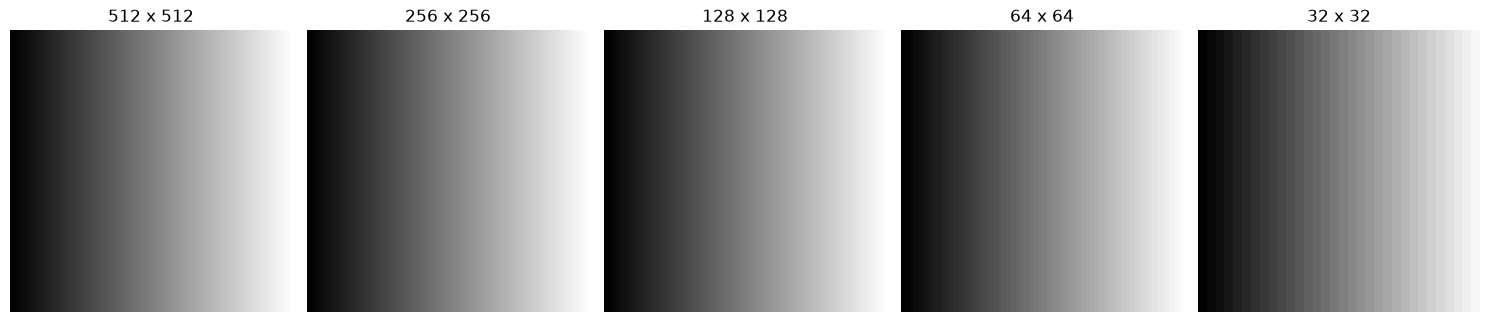

In [6]:
# Spatial Sampling

sizes = [512, 256, 128, 64, 32]

plt.figure(figsize=(15,8))
for i, size in enumerate(sizes):
    small = cv2.resize(
        gradient, (size, size),
        interpolation=cv2.INTER_NEAREST
    )

    plt.subplot(1, 5, i+1)
    plt.imshow(small, cmap="gray", vmin=0, vmax=255)
    plt.title(f"{size} x {size}")
    plt.axis("off")

plt.tight_layout()
plt.show()

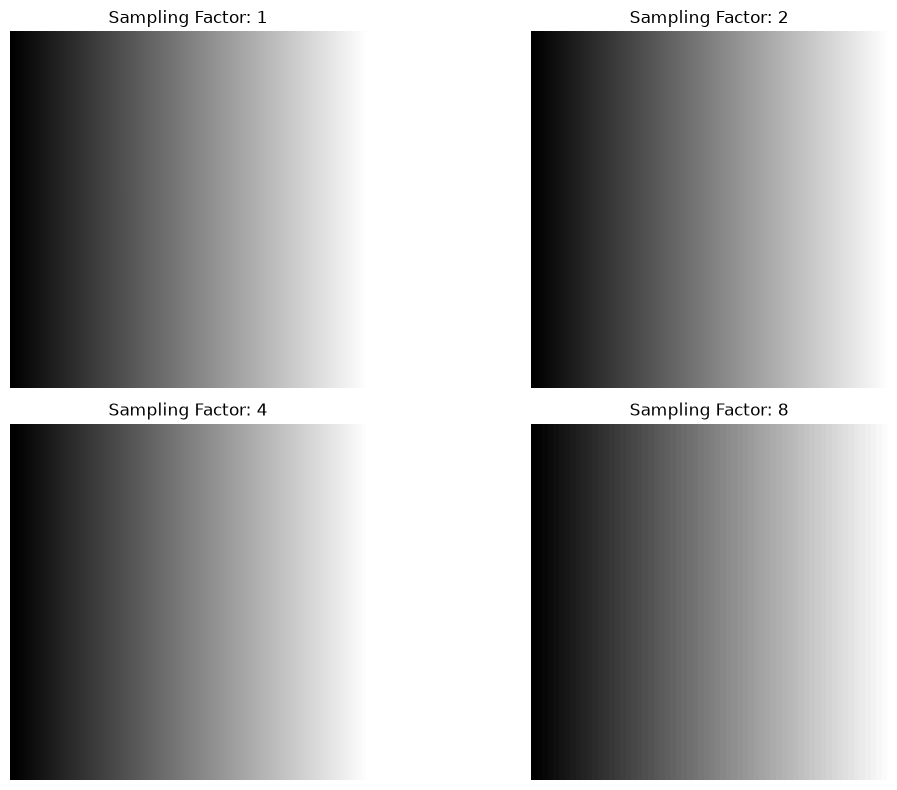

In [8]:
# Manual Image Sampling

sampling_factors = [1, 2, 4, 8]

plt.figure(figsize=(12,8))
for i, factor in enumerate(sampling_factors):
    sampled = gradient[::factor, ::factor]
    plt.subplot(2,2, i+1)
    plt.imshow(sampled, cmap="gray", vmin=0, vmax=255)
    plt.title(f"Sampling Factor: {factor}")
    plt.axis("off")

plt.tight_layout()
plt.show()

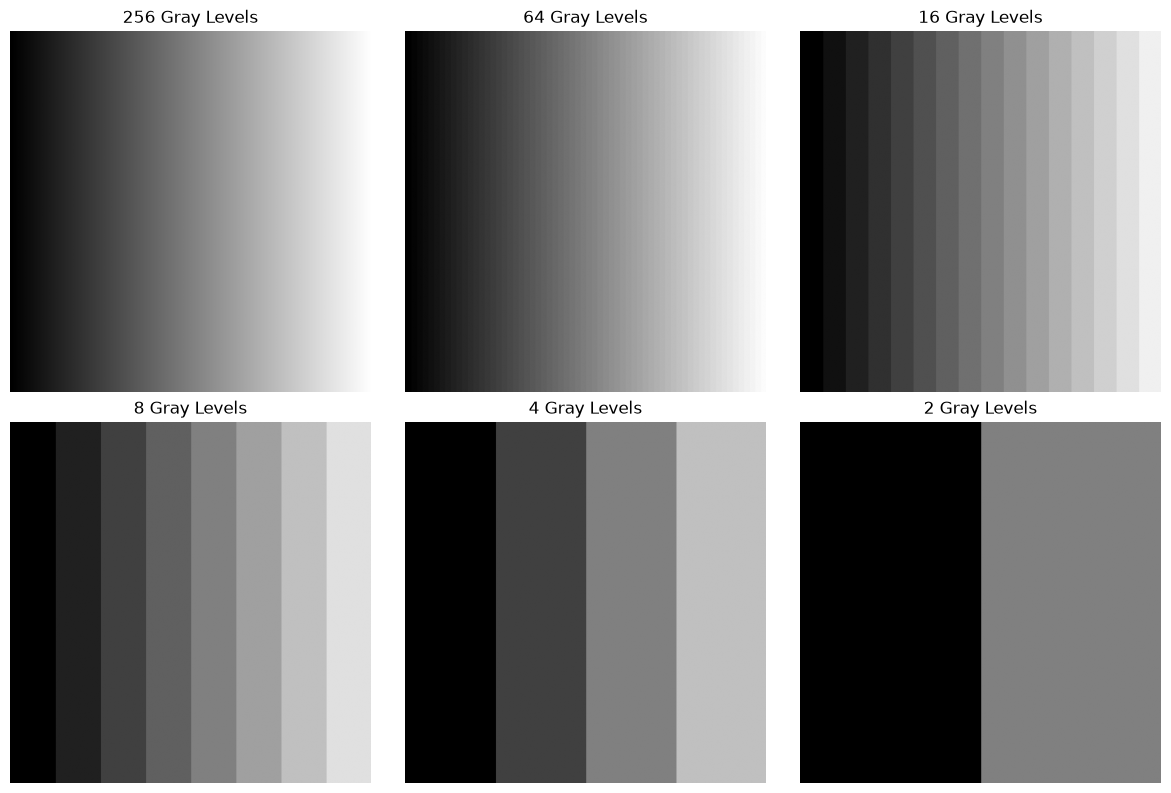

In [9]:
# Quantization

def quantization_image(image, levels):
    step = 256 / levels
    quantisized = np.floor(image / step) * step
    return np.clip(quantisized, 0, 255).astype(np.uint8)

levels = [256, 64, 16, 8, 4, 2]

plt.figure(figsize=(12, 8))
for i, level in enumerate(levels):
    q_image = quantization_image(gradient, level)
    plt.subplot(2, 3, i+1)
    plt.imshow(q_image, cmap="gray", vmin=0, vmax=255)
    plt.title(f"{level} Gray Levels")
    plt.axis("off")

plt.tight_layout()
plt.show()